In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

# 1. Load the dataset (using the updated path)
df = pd.read_csv('../data/NAB/data/realKnownCause/machine_temperature_system_failure.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])

# 2. Load the anomaly labels
with open('../data/NAB/labels/combined_windows.json', 'r') as f:
    labels = json.load(f)

# 3. Extract the specific anomaly windows for our file
file_key = 'realKnownCause/machine_temperature_system_failure.csv'
anomaly_windows = labels.get(file_key, [])

print(f"Found {len(anomaly_windows)} anomaly windows for this file:")
for window in anomaly_windows:
    print(f"  Start: {window[0]} | End: {window[1]}")

Found 4 anomaly windows for this file:
  Start: 2013-12-10 06:25:00.000000 | End: 2013-12-12 05:35:00.000000
  Start: 2013-12-15 17:50:00.000000 | End: 2013-12-17 17:00:00.000000
  Start: 2014-01-27 14:20:00.000000 | End: 2014-01-29 13:30:00.000000
  Start: 2014-02-07 14:55:00.000000 | End: 2014-02-09 14:05:00.000000


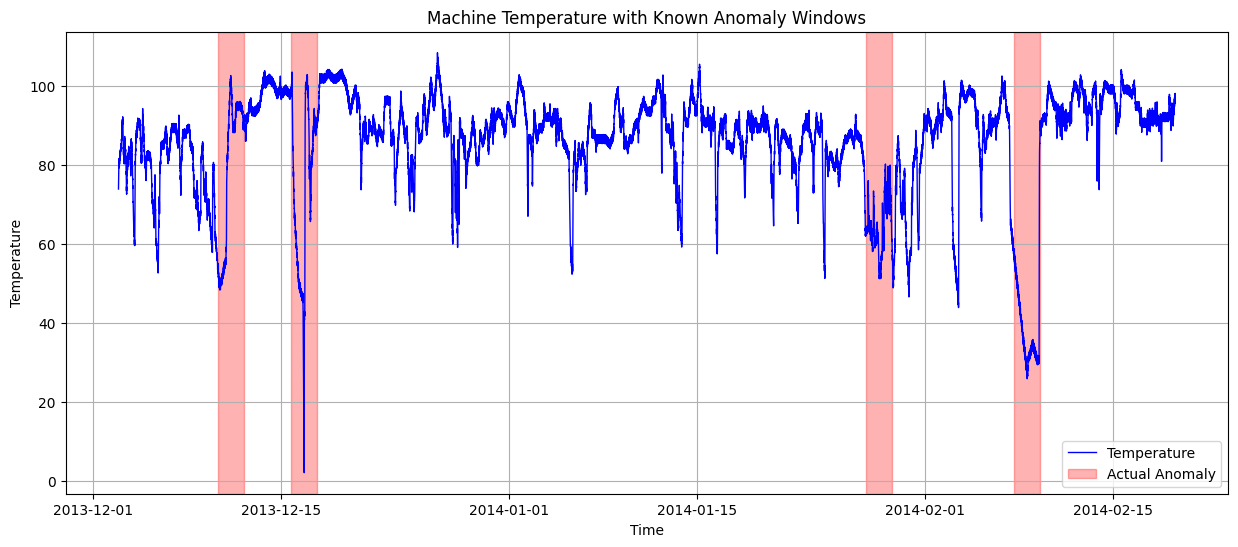

In [2]:
plt.figure(figsize=(15, 6))

# Plot the main temperature line
plt.plot(df['timestamp'], df['value'], color='blue', linewidth=1, label='Temperature')

# Highlight the anomaly windows in red
for i, window in enumerate(anomaly_windows):
    start_time = pd.to_datetime(window[0])
    end_time = pd.to_datetime(window[1])
    
    # Add a red shaded region for the anomaly window
    # We only add the label once so it doesn't repeat in the legend
    plt.axvspan(start_time, end_time, color='red', alpha=0.3, label='Actual Anomaly' if i == 0 else "")

plt.title('Machine Temperature with Known Anomaly Windows')
plt.xlabel('Time')
plt.ylabel('Temperature')
plt.grid(True)
plt.legend()
plt.show()

In [3]:
# Load the EC2 CPU utilization dataset
df_ec2 = pd.read_csv('../data/NAB/data/realAWSCloudwatch/ec2_cpu_utilization_ac20cd.csv')
df_ec2['timestamp'] = pd.to_datetime(df_ec2['timestamp'])

# Extract the specific anomaly windows for this file
file_key_ec2 = 'realAWSCloudwatch/ec2_cpu_utilization_ac20cd.csv'
anomaly_windows_ec2 = labels.get(file_key_ec2, [])

print(f"Found {len(anomaly_windows_ec2)} anomaly windows for this file:")
for window in anomaly_windows_ec2:
    print(f"  Start: {window[0]} | End: {window[1]}")

Found 1 anomaly windows for this file:
  Start: 2014-04-14 07:49:00.000000 | End: 2014-04-15 17:34:00.000000


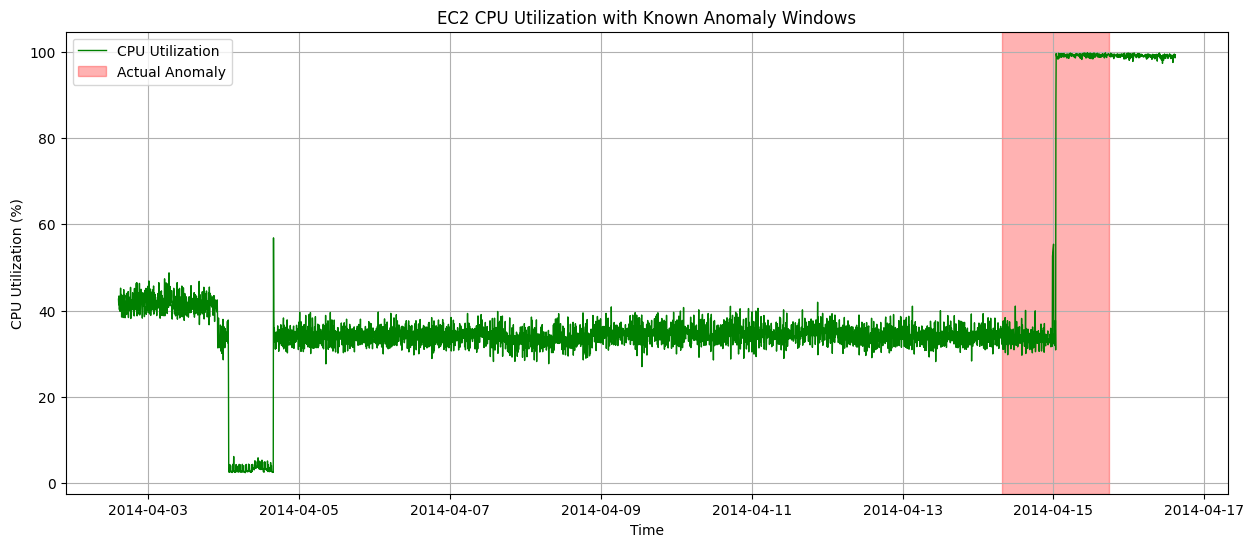

In [4]:
plt.figure(figsize=(15, 6))

# Plot the EC2 CPU utilization line
plt.plot(df_ec2['timestamp'], df_ec2['value'], color='green', linewidth=1, label='CPU Utilization')

# Highlight the anomaly windows in red
for i, window in enumerate(anomaly_windows_ec2):
    start_time = pd.to_datetime(window[0])
    end_time = pd.to_datetime(window[1])
    
    plt.axvspan(start_time, end_time, color='red', alpha=0.3, label='Actual Anomaly' if i == 0 else "")

plt.title('EC2 CPU Utilization with Known Anomaly Windows')
plt.xlabel('Time')
plt.ylabel('CPU Utilization (%)')
plt.grid(True)
plt.legend()
plt.show()

In [5]:
# Load the Traffic Speed dataset
df_traffic = pd.read_csv('../data/NAB/data/realTraffic/speed_7578.csv')
df_traffic['timestamp'] = pd.to_datetime(df_traffic['timestamp'])

# Extract the specific anomaly windows for this file
file_key_traffic = 'realTraffic/speed_7578.csv'
anomaly_windows_traffic = labels.get(file_key_traffic, [])

print(f"Found {len(anomaly_windows_traffic)} anomaly windows for this file:")
for window in anomaly_windows_traffic:
    print(f"  Start: {window[0]} | End: {window[1]}")

Found 4 anomaly windows for this file:
  Start: 2015-09-11 15:34:00.000000 | End: 2015-09-11 17:54:00.000000
  Start: 2015-09-15 13:26:00.000000 | End: 2015-09-15 15:54:00.000000
  Start: 2015-09-16 13:04:00.000000 | End: 2015-09-16 15:20:00.000000
  Start: 2015-09-16 16:00:00.000000 | End: 2015-09-16 18:20:00.000000


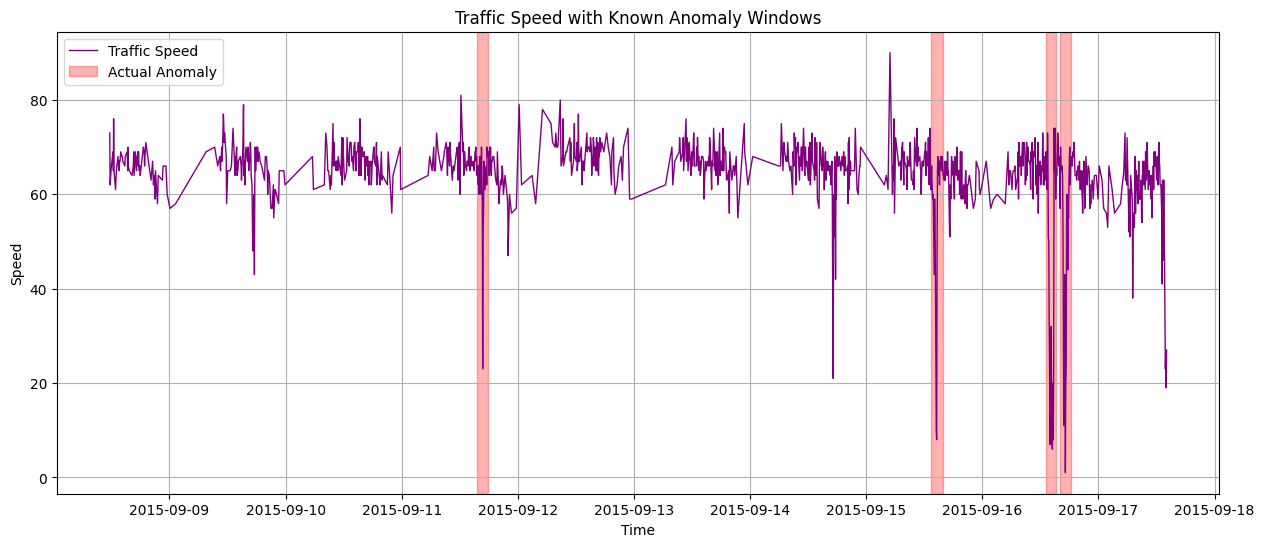

In [6]:
plt.figure(figsize=(15, 6))

# Plot the Traffic Speed line
plt.plot(df_traffic['timestamp'], df_traffic['value'], color='purple', linewidth=1, label='Traffic Speed')

# Highlight the anomaly windows in red
for i, window in enumerate(anomaly_windows_traffic):
    start_time = pd.to_datetime(window[0])
    end_time = pd.to_datetime(window[1])
    
    plt.axvspan(start_time, end_time, color='red', alpha=0.3, label='Actual Anomaly' if i == 0 else "")

plt.title('Traffic Speed with Known Anomaly Windows')
plt.xlabel('Time')
plt.ylabel('Speed')
plt.grid(True)
plt.legend()
plt.show()